In [2]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import PendulumEnv
from data_processors import KernelDataProcessor
import copy
import math
import imageio
import random

/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# plots pendulum friction  using kernel

In [3]:
paths = [
        #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        # '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0.1}_07_10-16_50_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        # '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0.2}_07_10-18_26_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        # '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0.3}_07_10-15_20_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        # '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0.4}_07_10-18_11_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00'

        #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test{0}_07_12-02_05_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test_tol1e-4{0}_07_12-12_17_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test_tol1e-4{0}_07_14-19_43_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test_100{0}_07_15-00_00_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test_150{0}_07_18-02_11_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00',
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test_50{0}_07_22-14_23_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00'


]  

In [4]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

#lab = ['friction 0.0','friction 0.1', 'friction 0.2', 'friction 0.3', 'friction 0.4', 'friction 0.5', '', '', '']
lab = ['no kl', 'kl 100', 'kl 150', 'kl 50']
print(len(all_performances))

4


-167.40638346735489
-195.9780322911639
-170.99050208507302
-197.6759051722121


<Figure size 640x480 with 0 Axes>

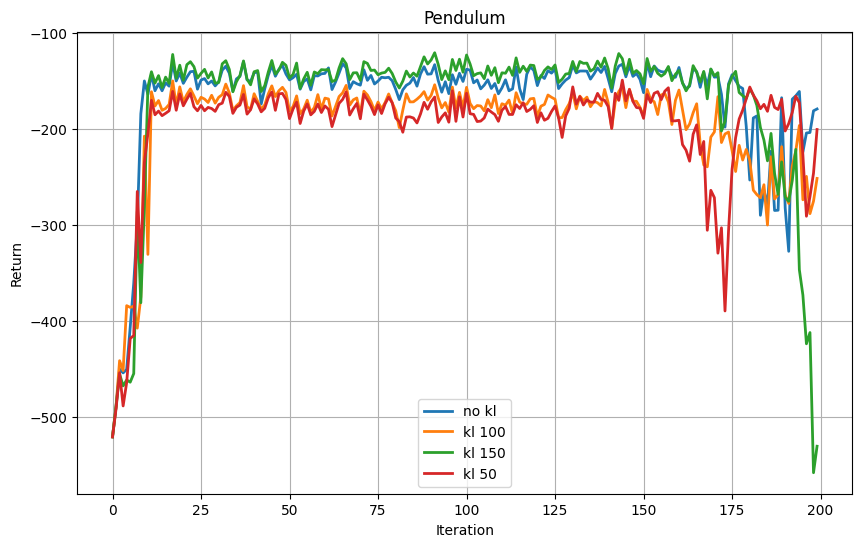

In [5]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

## Test policy



pol 0 fr 0

100%|██████████| 200/200 [00:17<00:00, 11.76it/s]


Mean reward: -524.0511936629638 Std reward: 209.91041482552595


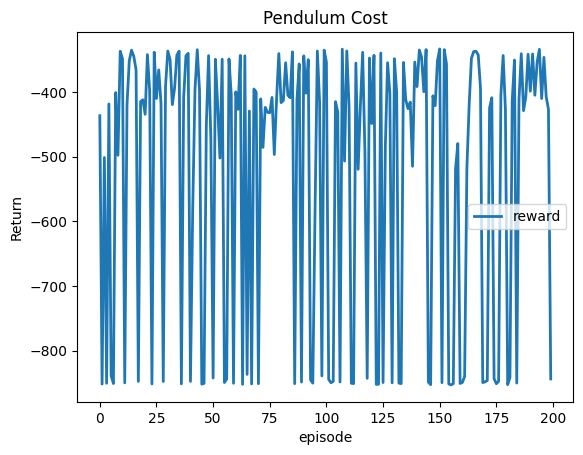

In [21]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.1

NUM_EPISODES = 200

START = "down"

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()

all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    env.reset(options={"start": START})
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
        if done:
            break
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

plt.title("Pendulum Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/plots/friction03-03_down")

frames = []
env.reset(options={"start": START})
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    obs = dp.transform(obs)
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave("/home/tedeschi_bpo/learn_RL/presentation/gifs/down.gif", frames, duration=33)

pol o.3 fr 0.3

100%|██████████| 200/200 [00:26<00:00,  7.63it/s]


Mean reward: -361.27506363828974 Std reward: 19.717357799510044


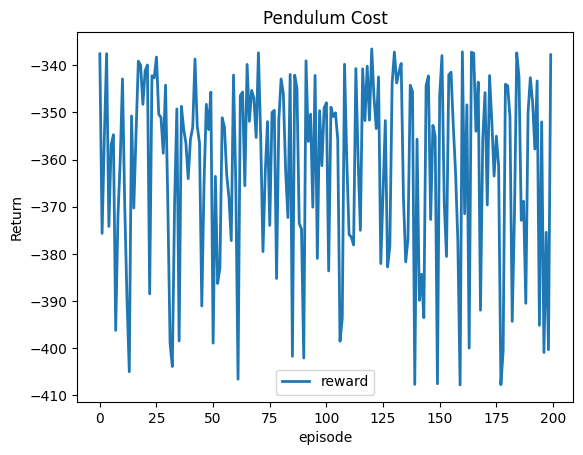

In [20]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.1

NUM_EPISODES = 200

START = "down"

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0.3}_07_10-15_20_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()

all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    env.reset(options={"start": START})
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
        if done:
            break
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

plt.title("Pendulum Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/plots/friction03-03_down")

frames = []
env.reset(options={"start": START})
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    obs = dp.transform(obs)
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

#imageio.mimsave("/home/tedeschi_bpo/learn_RL/presentation/gifs/friction03-03_down.gif", frames, duration=33)

pol 0.3 fr 0.3

100%|██████████| 200/200 [00:10<00:00, 19.32it/s]


Mean reward: -431.56628348694016 Std reward: 67.5913826451637 Median -411.103805520778


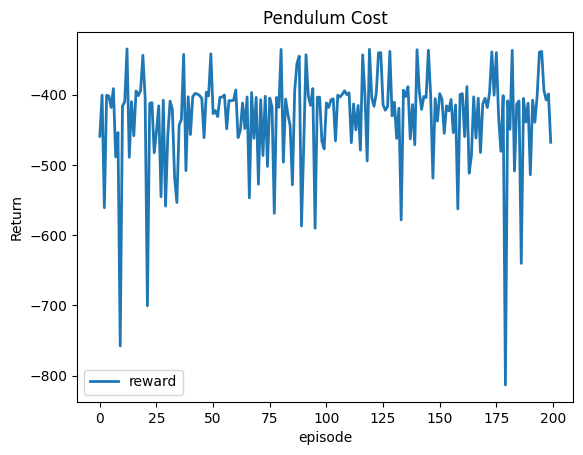

In [43]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.5

NUM_EPISODES = 200

START = "down"

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/onpolicy/0.5test{0.3}_07_01-12_17_PG_200_pendulum_200_099_constant_00001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()

all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    env.reset(options={"start": START})
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
        if done:
            break
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
median_episode_reward = np.median(all_episode_rewards)

print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward,
        "Median", median_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

plt.title("Pendulum Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/plots/friction03-03_down")

frames = []
env.reset(options={"start": START})
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    obs = dp.transform(obs)
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

#imageio.mimsave("/home/tedeschi_bpo/learn_RL/presentation/gifs/friction03-03_down.gif", frames, duration=33)

# Life Long

## No retrain

  0%|          | 2/5000 [00:00<04:54, 16.99it/s]

current mu = 0


 20%|██        | 1002/5000 [01:04<03:42, 17.97it/s]

current mu = 0.1


 40%|████      | 2002/5000 [02:04<03:09, 15.85it/s]

...

current mu = 0.3


 80%|████████  | 4002/5000 [04:07<00:58, 17.02it/s]

current mu = 0.4


100%|██████████| 5000/5000 [05:06<00:00, 16.29it/s]


Mean reward: -5.008894462182435 Std reward: 49.86626434519569


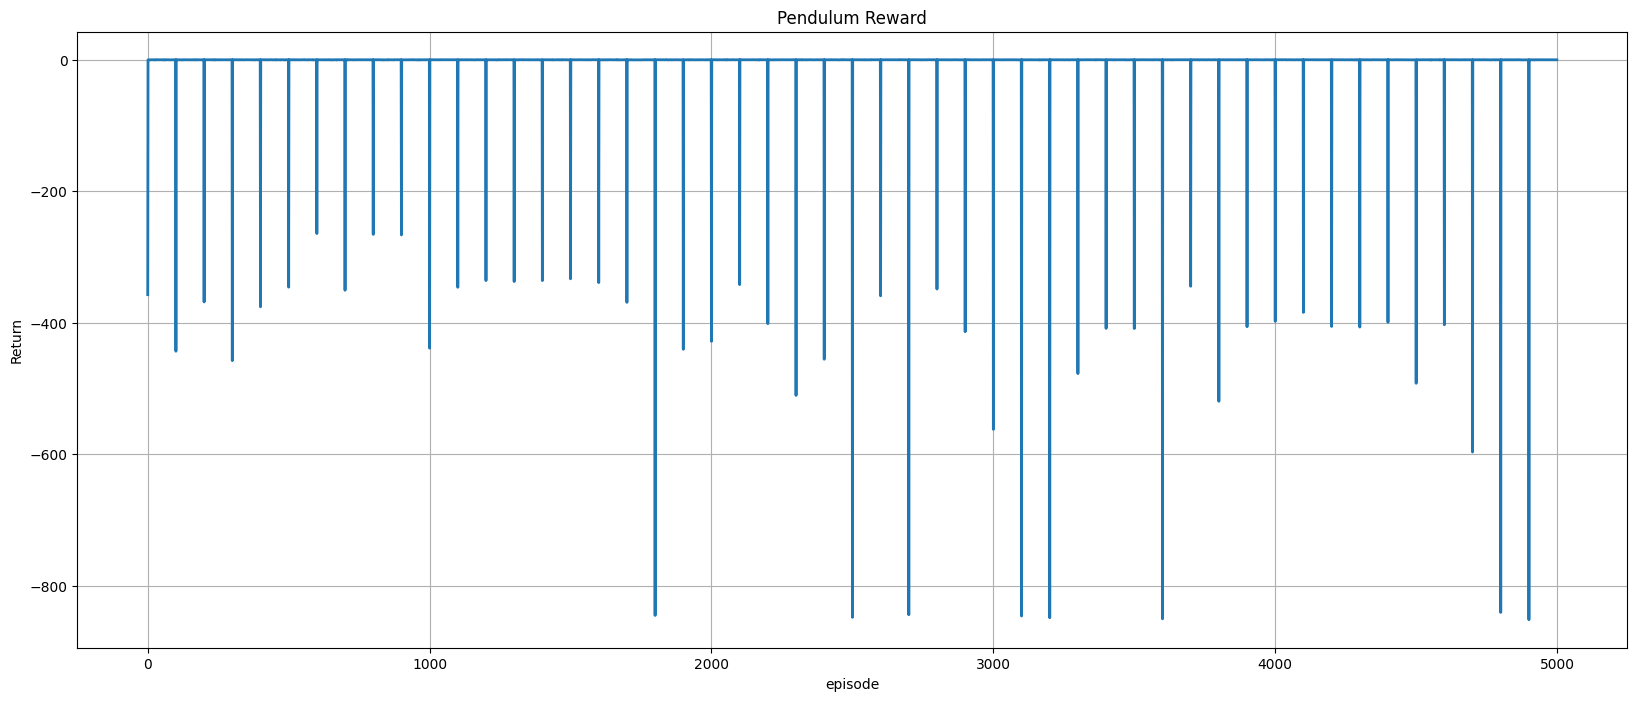

In [5]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.25

NUM_EPISODES = 5000

START = "up"

SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            #parameters= np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test_tol1e-4{0}_07_14-19_43_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/noretrain")

# plt.clf()
# plt.figure(figsize=(50, 8))
# plt.plot(all_episode_rewards, linewidth=2, label="reward")
# plt.title("Pendulum Reward")
# plt.xlabel("episode")
# plt.ylabel("Return")
# plt.grid()
# plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/noretrain_large")



  0%|          | 0/5000 [00:00<?, ?it/s]

current mu = 0


 20%|██        | 1000/5000 [04:51<23:22,  2.85it/s]

current mu = 0.1


 40%|████      | 2000/5000 [09:11<10:45,  4.65it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4000/5000 [18:10<03:55,  4.24it/s]

current mu = 0.4


100%|██████████| 5000/5000 [23:01<00:00,  3.62it/s]


Mean reward: -4.529682795202686 Std reward: 44.31093483805123


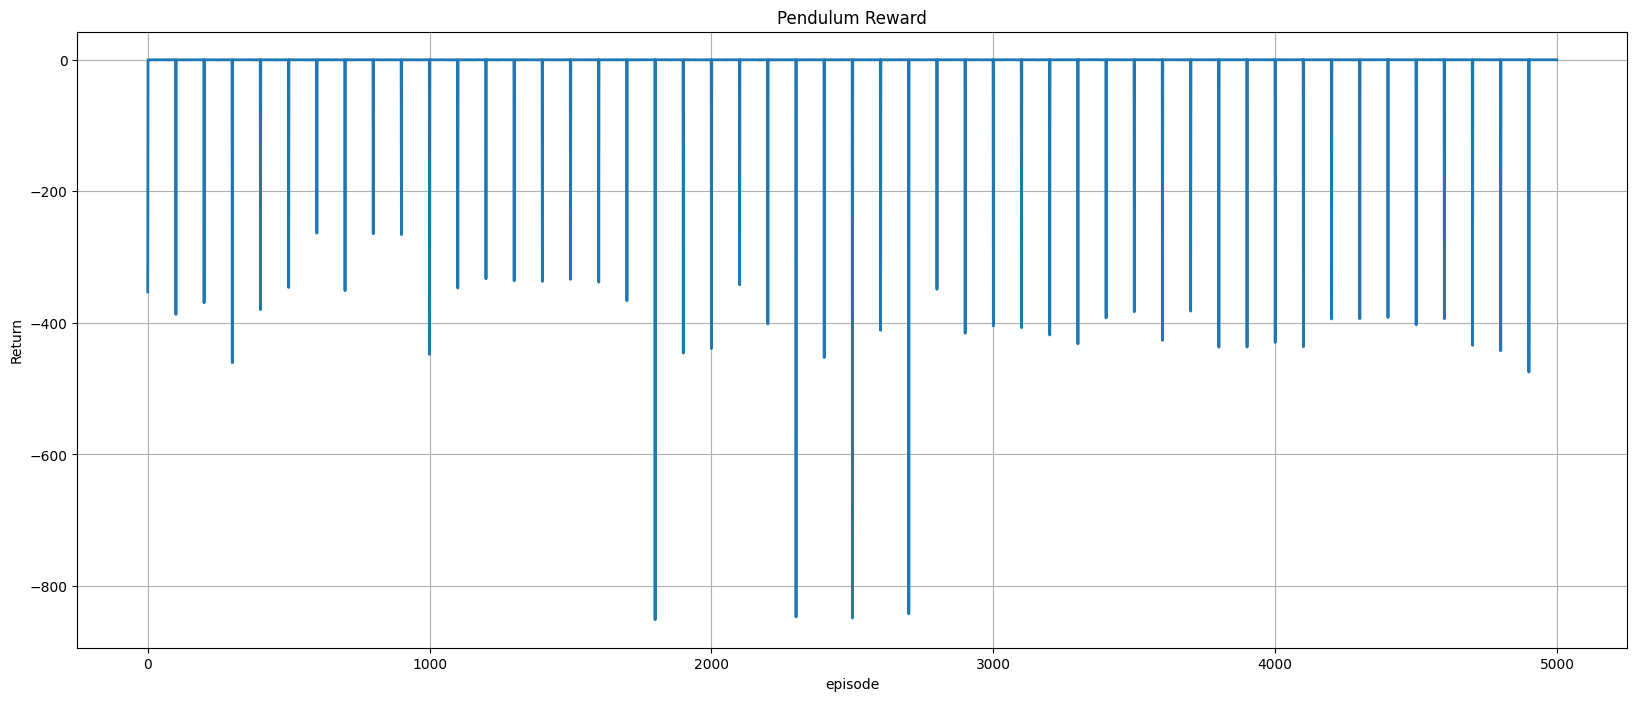

In [4]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.3}_07_10-19_21_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")

# plt.clf()
# plt.figure(figsize=(50, 8))
# plt.plot(all_episode_rewards, linewidth=2, label="reward")
# plt.title("Pendulum Reward")
# plt.xlabel("episode")
# plt.ylabel("Return")
# plt.grid()
# plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03_large")


  0%|          | 0/5000 [00:00<?, ?it/s]

current mu = 0


 20%|██        | 1000/5000 [05:16<27:25,  2.43it/s]

current mu = 0.1


 40%|████      | 2000/5000 [09:28<09:27,  5.28it/s]

...

current mu = 0.3


 80%|████████  | 4000/5000 [19:19<04:26,  3.75it/s]

current mu = 0.4
 ------- Simulating retrain at mu = 0.4


100%|██████████| 5000/5000 [24:13<00:00,  3.44it/s]


Mean reward: -4.263825826207215 Std reward: 39.56512436918276


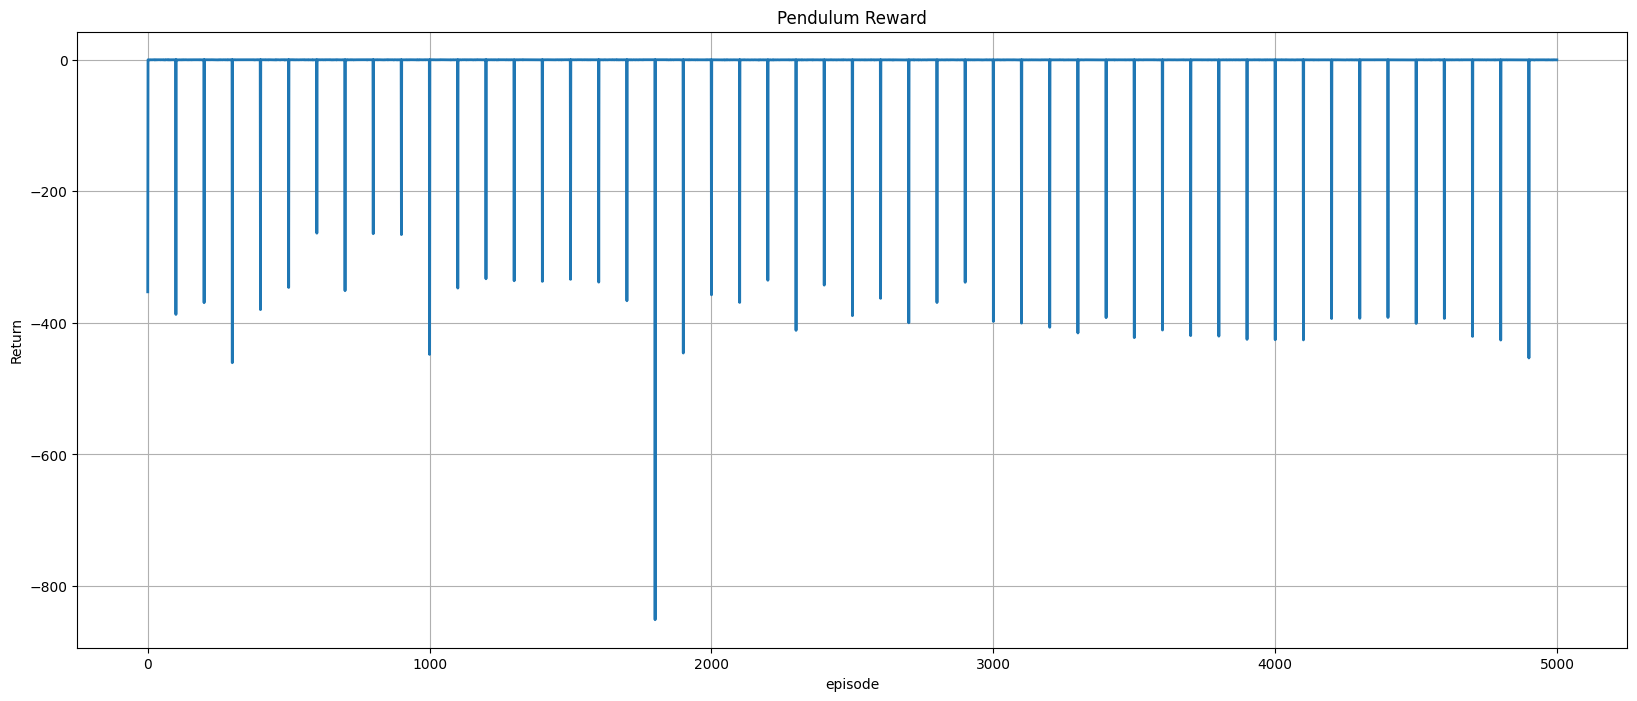

In [5]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 2000 :
        print(" ------- Simulating retrain at mu = 0.2")
        pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.2}_07_10-23_53_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
    if i == 4000 :
        print(" ------- Simulating retrain at mu = 0.4")
        # pol = DeepGaussianPolicy(
        #     parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0.2/test_0.2{0.4}_06_29-11_48_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
        #     input_size=s_dim,
        #     output_size=a_dim,
        #     model=copy.deepcopy(net),
        #     model_desc=copy.deepcopy(model_desc),
        #     std_dev=STD_DEV,
        #     std_decay=0,
        #     std_min=1e-6
        # )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain0204")

# plt.clf()
# plt.figure(figsize=(50, 8))
# plt.plot(all_episode_rewards, linewidth=2, label="reward")
# plt.title("Pendulum Reward")
# plt.xlabel("episode")
# plt.ylabel("Return")
# plt.grid()
# plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain0204_large")


  0%|          | 0/5000 [00:00<?, ?it/s]

current mu = 0


 20%|██        | 1000/5000 [03:55<13:41,  4.87it/s]

current mu = 0.1
 ------- Simulating retrain at mu = 0.1


 40%|████      | 2001/5000 [08:44<07:50,  6.38it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4000/5000 [16:53<05:09,  3.23it/s]

current mu = 0.4
 ------- Simulating retrain at mu = 0.4


100%|██████████| 5000/5000 [20:39<00:00,  4.03it/s]


Mean reward: -3.975327282183116 Std reward: 38.03242047685475


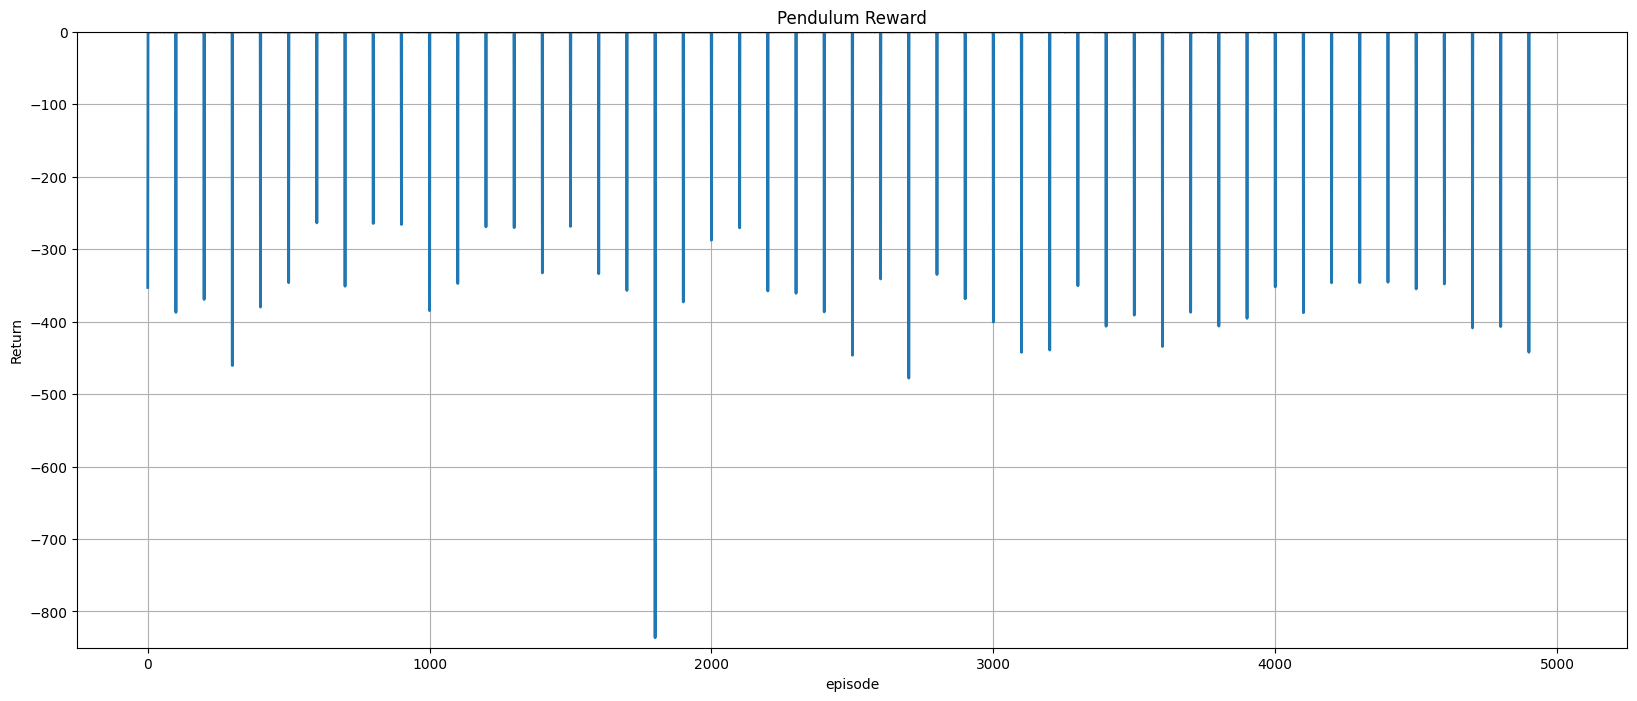

In [ ]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)


env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
        
    if i == 1000 :
        print(" ------- Simulating retrain at mu = 0.1")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.1}_07_11-01_07_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    if i == 2000 :
        print(" ------- Simulating retrain at mu = 0.2")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom01/test{0.2}_07_11-13_21_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom02/test{0.3}_07_11-01_41_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
    )
    if i == 4000 :
        print(" ------- Simulating retrain at mu = 0.4")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom03/test{0.4}_07_11-13_26_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.ylim(-850, 0)
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain01-02-03-04")

# plt.clf()
# plt.figure(figsize=(50, 8))
# plt.plot(all_episode_rewards, linewidth=2, label="reward")
# plt.title("Pendulum Reward")
# plt.xlabel("episode")
# plt.ylabel("Return")
# plt.grid()
# plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain01-02-03-04")


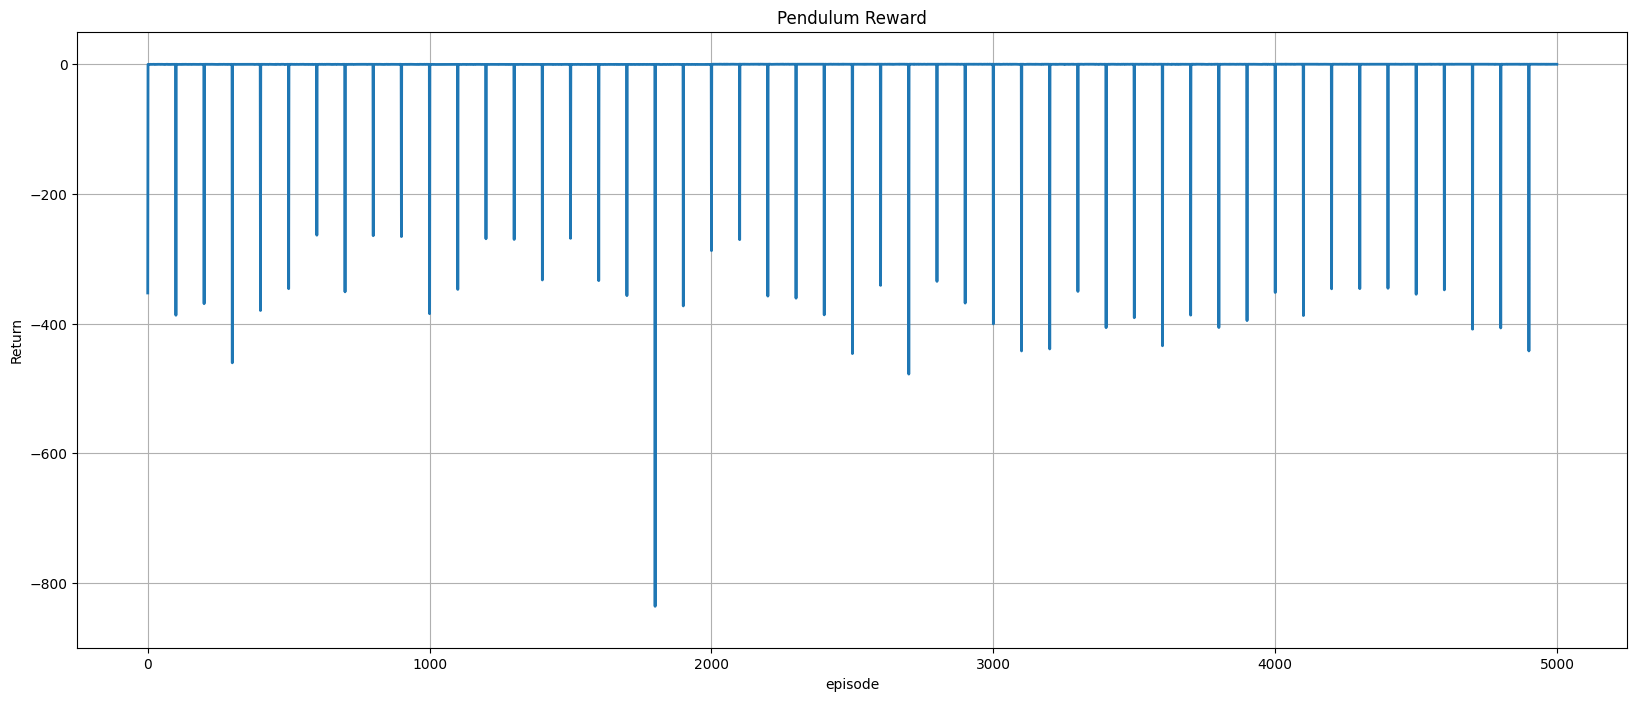

In [13]:
plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.ylim(-900, 50)
plt.grid()
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain01-02-03-04")


## plots retrain

In [55]:
paths = [
    #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.3}_07_10-22_25_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.2}_07_10-23_53_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom02/test{0.4}_07_10-22_33_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.1}_07_11-01_07_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom01/test{0.2}_07_11-13_21_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom02/test{0.3}_07_11-01_41_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom03/test{0.4}_07_11-13_26_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00'



]

In [56]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

#lab = ['friction 0.0','friction 0.1', 'friction 0.2', 'friction 0.3', 'friction 0.4', 'friction 0.5']
lab = ['0.1', '0.2', '0.3', '0.4']

-156.66134994915058
-163.56406999708514
-194.3087825886675
-188.10611648279556


<Figure size 640x480 with 0 Axes>

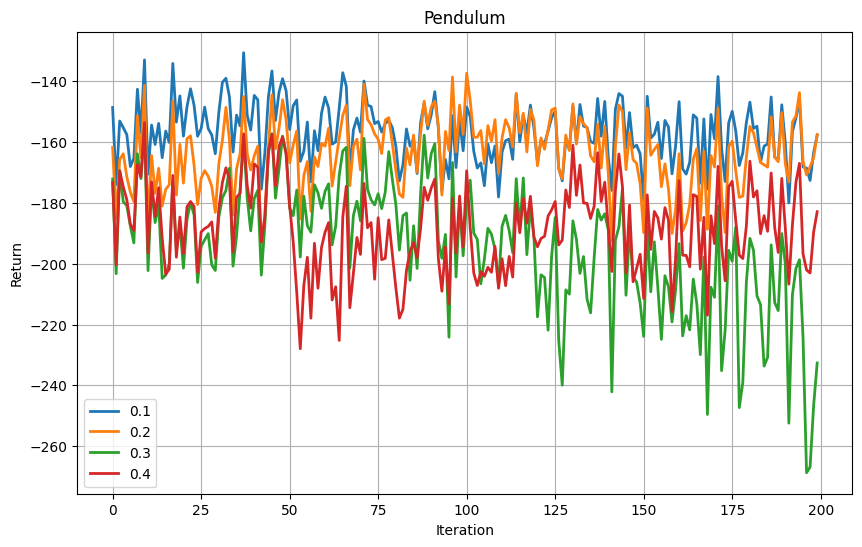

In [57]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [ ]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

Path 1 - Mean Cost: -180.72, Std Dev: 15.02


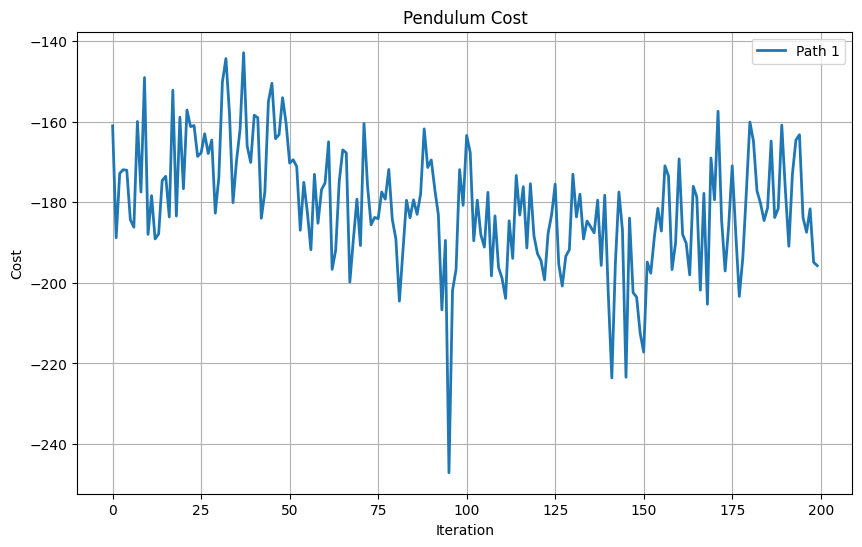

In [34]:
# cost retarining at mu 0.3
paths = [
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.3}_07_10-22_25_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0'
]
all_costs = []
for path in paths:
    costs = load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()




Path 1 - Mean Cost: -166.03, Std Dev: 10.63
Path 2 - Mean Cost: -185.67, Std Dev: 13.74


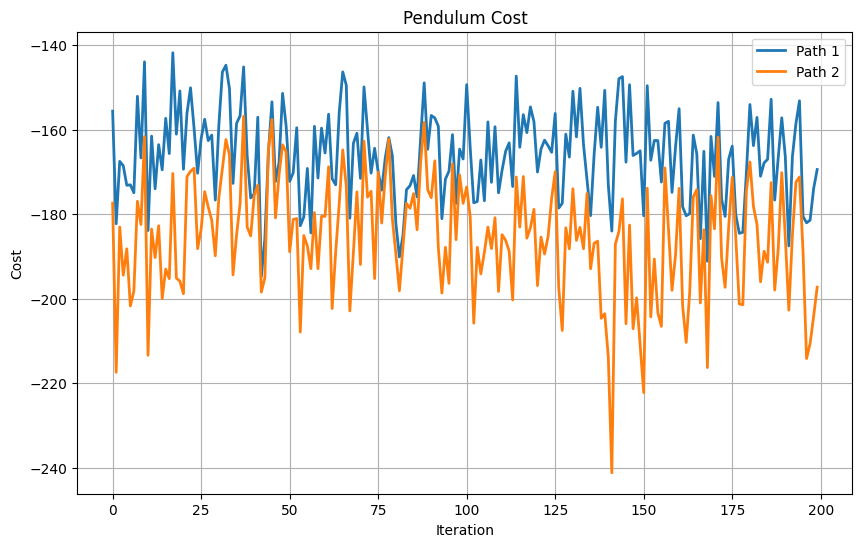

In [53]:
# cost retarining at mu 0.2 e 0.4
paths = [
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.2}_07_10-23_53_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0',
        '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom02/test{0.4}_07_10-22_33_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0'

]

all_costs = []
for path in paths:
    costs = load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()




Path 1 - Mean Cost: -157.13, Std Dev: 10.13
Path 2 - Mean Cost: -163.54, Std Dev: 11.33
Path 3 - Mean Cost: -194.47, Std Dev: 20.50
Path 4 - Mean Cost: -188.80, Std Dev: 15.50


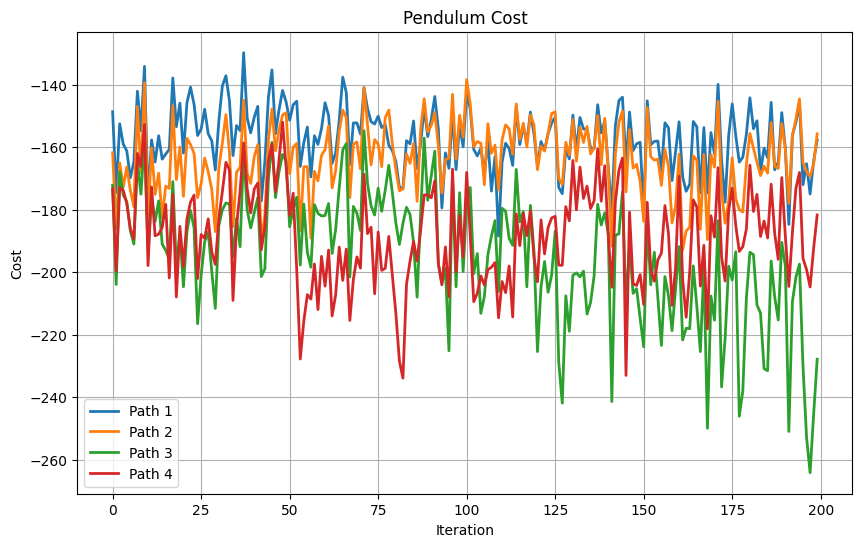

In [59]:
paths = [
     '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.1}_07_11-01_07_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom01/test{0.2}_07_11-13_21_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom02/test{0.3}_07_11-01_41_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom03/test{0.4}_07_11-13_26_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0'

]

all_costs = []
for path in paths:
    costs = load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()

Path 1 - Mean Cost: -169.89, Std Dev: 67.57


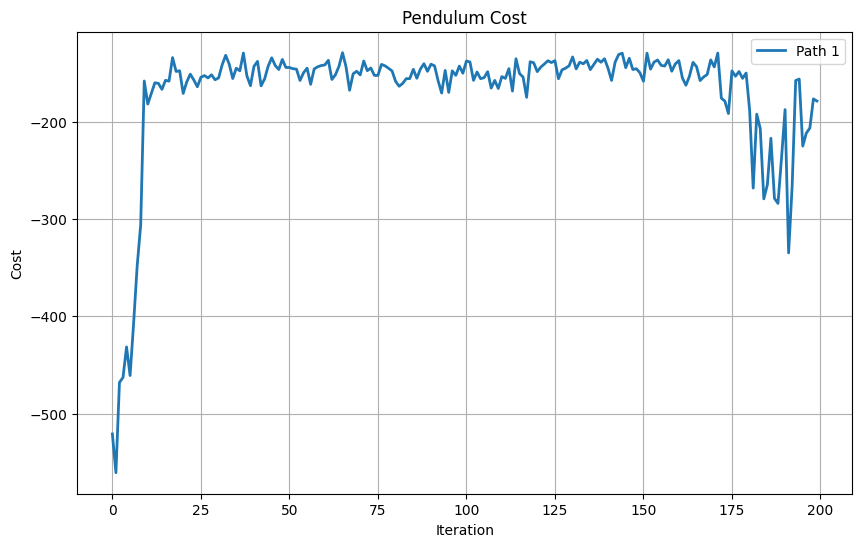

In [ ]:
paths = [
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test_tol1e-4{0}_07_14-19_43_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0'
]

all_costs = []
for path in paths:
    costs = load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()

Path 1 - Mean Cost: -197.81, Std Dev: 87.59


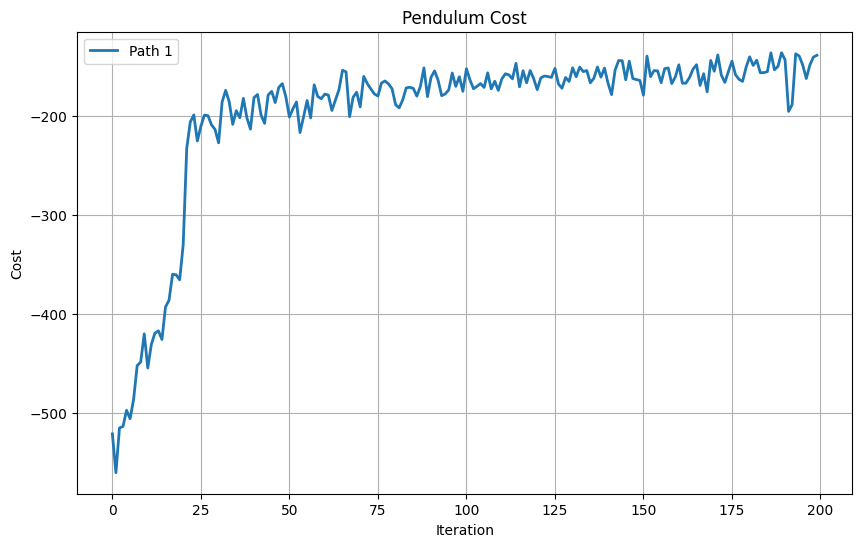

In [8]:
paths = [
    #'/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test_100{0}_07_15-00_00_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0',
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl/test{0}_07_12-02_05_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0'
]
all_costs = []
for path in paths:
    costs = load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()

  0%|          | 2/5000 [00:00<04:25, 18.85it/s]

current mu = 0


 20%|██        | 1004/5000 [00:48<03:14, 20.52it/s]

current mu = 0.1


 40%|████      | 2003/5000 [01:37<02:25, 20.63it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [03:19<00:48, 20.71it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:07<00:00, 20.21it/s]


Mean reward: -4.285423389825812 Std reward: 36.476634263392114


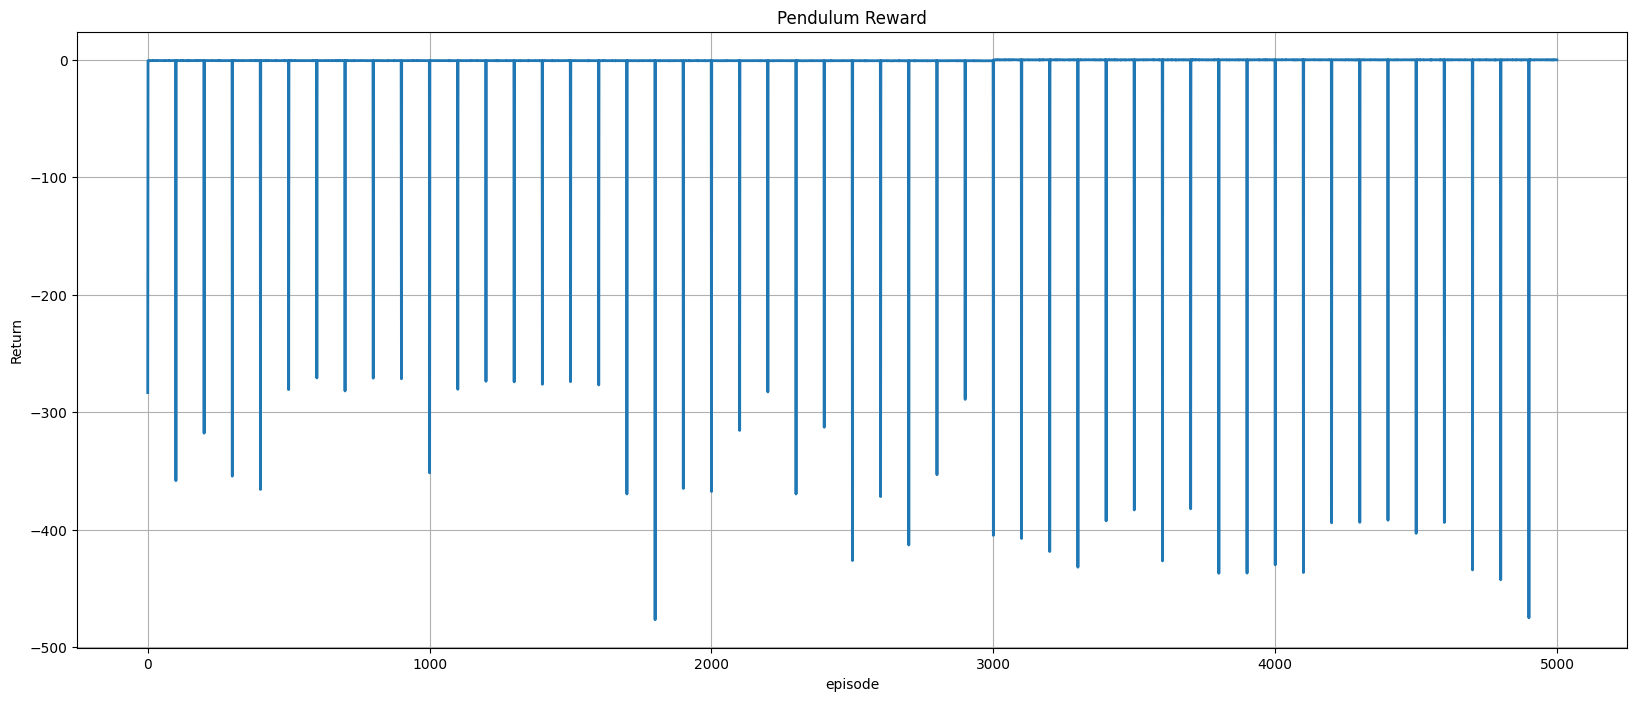

In [6]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/0-0.3test_50{0.3}_07_23-23_37_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.3}_07_10-19_21_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")

# plt.clf()
# plt.figure(figsize=(50, 8))
# plt.plot(all_episode_rewards, linewidth=2, label="reward")
# plt.title("Pendulum Reward")
# plt.xlabel("episode")
# plt.ylabel("Return")
# plt.grid()
# plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03_large")
